In [14]:
import pandas as pd
import glob
import os
from sklearn.metrics import average_precision_score, auc
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr
from scipy.stats import mannwhitneyu

In [15]:
from variant_tasks import *

In [16]:
os.environ['DART_WORK_DIR'] = '/oak/stanford/groups/akundaje/arpitas/dart-eval'
work_dir = os.environ.get("DART_WORK_DIR", "")

unique label values label
False    77999
True      6821
Name: count, dtype: int64
African caQTL Mann Whitney pVal: 0.906671227931247
ARSENAL-CNN African Significant caQTLs


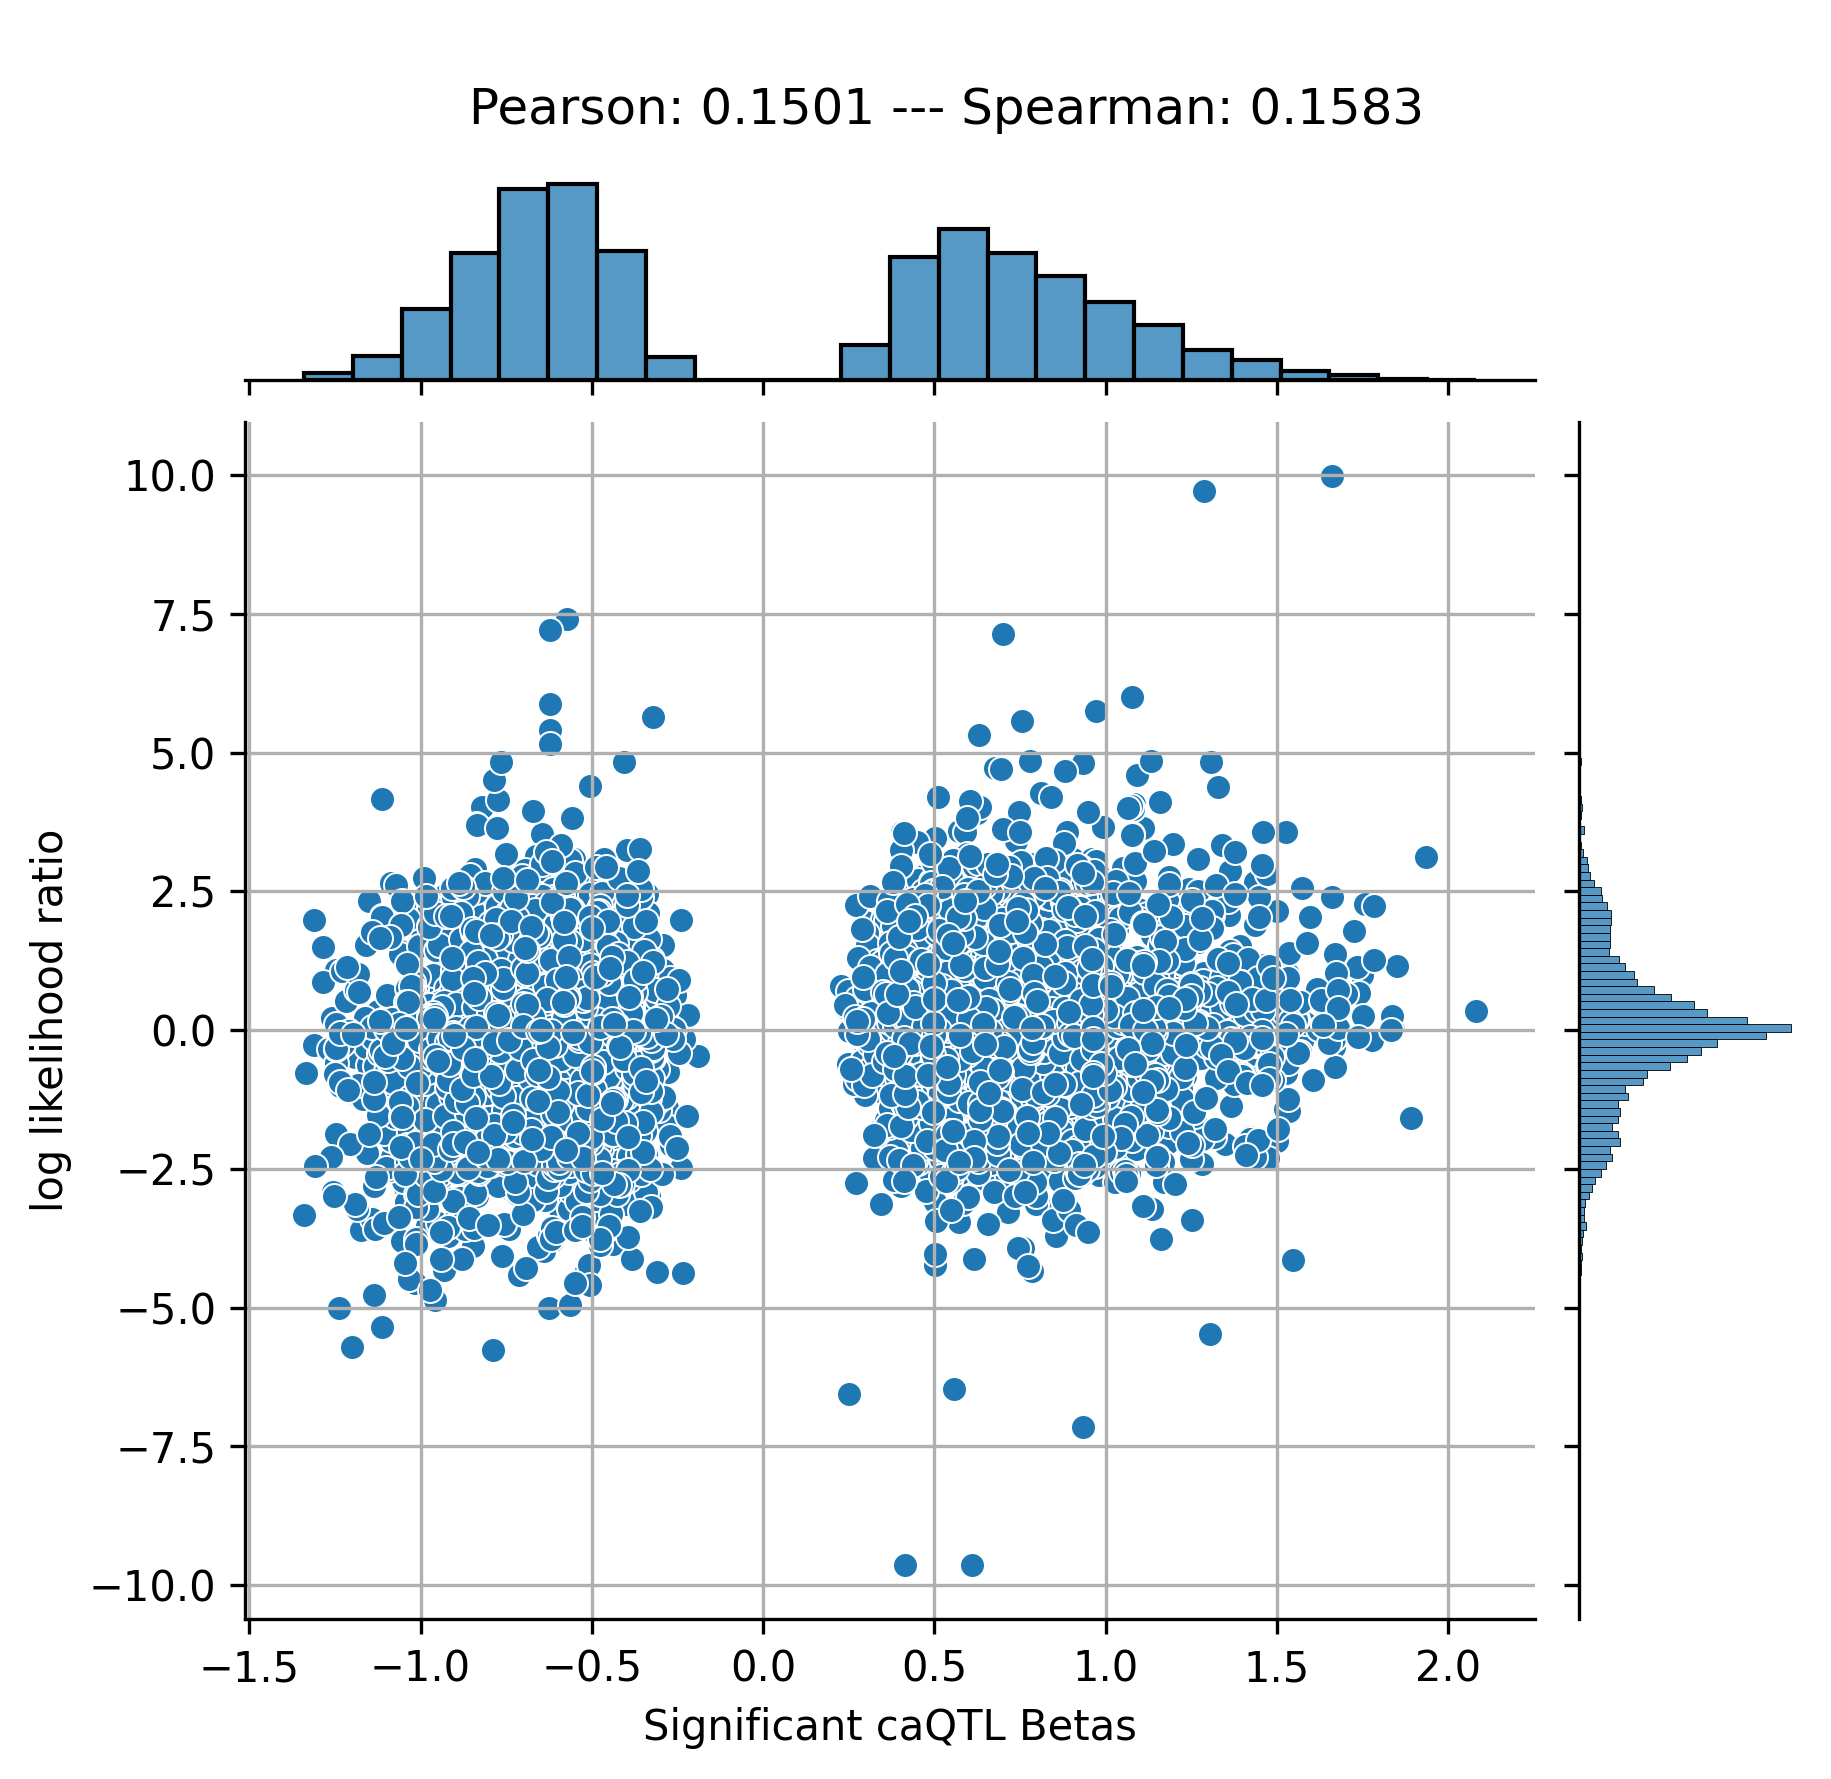

0.0849470449313812 0.49518671818292065 0.1500607404203686 0.1583196160289361
unique label values var.label
-1    26813
 1      560
Name: count, dtype: int64
ARSENAL-CNN Yoruba Significant dsQTLs


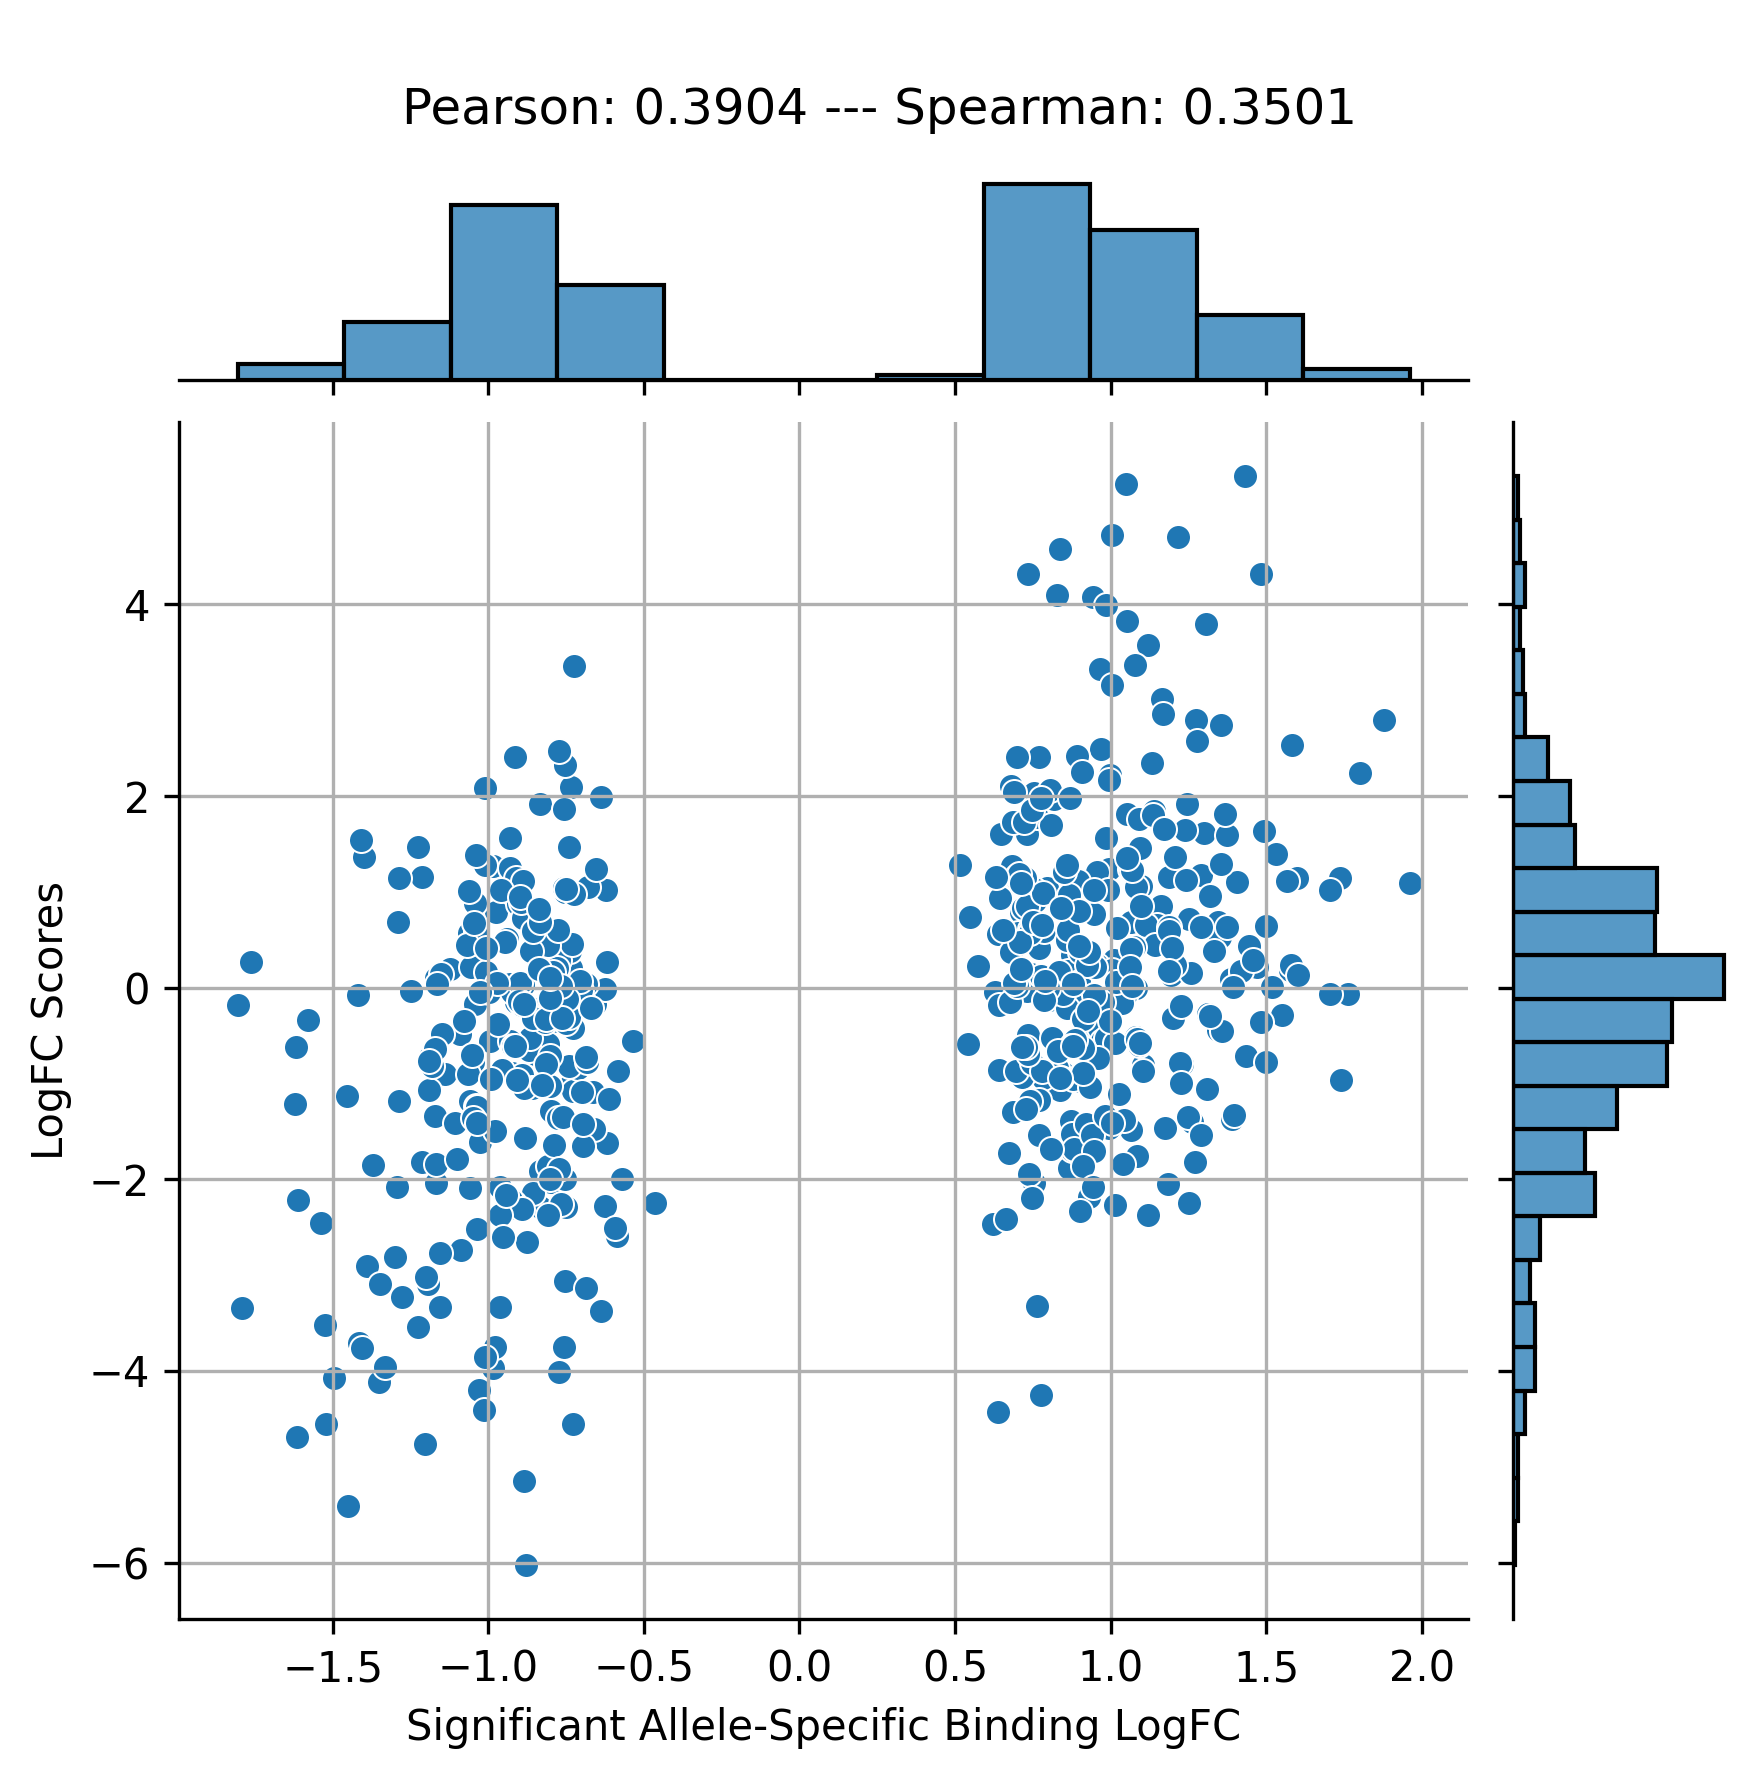

0.02687435114316402 0.5510108369607494 0.3903658555632843 0.35006955171846077


In [91]:
model_names=["ARSENAL"]
models = ["ARSENAL-CNN"]
# model_path = os.path.join(work_dir, "task_5_variant_effect_prediction/outputs/zero_shot/likelihoods")
africa_path = "/mnt/lab_data2/regulatory_lm/scratch/transformer_test/run_20251231_230449/dart_eval_task_5_ckpt149/african.tsv"
yoruba_path = "/mnt/lab_data2/regulatory_lm/scratch/transformer_test/run_20251231_230449/dart_eval_task_5_ckpt149/yoruban.tsv"

afr_counts_pvals = []
afr_counts_auprc = []
afr_counts_auroc = []
afr_counts_pearson = []
afr_counts_spearman = []

yoruba_counts_pvals = []
yoruba_counts_auprc = []
yoruba_counts_auroc = []
yoruba_counts_pearson = []
yoruba_counts_spearman = []

for model_name, model in zip(model_names, models):
    filtered_var_afr_caQTLs_df_ctrl, filtered_var_afr_caQTLs_df_sig = sig_ctrl_variants_Afr_CaQTLs(africa_path)
    filtered_var_afr_caQTLs_df_ctrl, ctrl_afr_countss = compute_change(filtered_var_afr_caQTLs_df_ctrl)
    filtered_var_afr_caQTLs_df_sig, sig_afr_countss = compute_change(filtered_var_afr_caQTLs_df_sig)
    afr_stat, afr_pval = mannwhitneyu(ctrl_afr_countss, sig_afr_countss, alternative="less")
    afr_counts_pvals += [afr_pval]
    print("African caQTL Mann Whitney pVal:", afr_pval)
    print(f"{model} African Significant caQTLs")
    pearson, spearman = beta_logfc(filtered_var_afr_caQTLs_df_sig, "", "log likelihood ratio")
    auprc, auroc = get_precision_recall_auc(ctrl_afr_countss, sig_afr_countss)
    afr_counts_auprc += [auprc]
    afr_counts_auroc += [auroc]
    afr_counts_pearson += [pearson]
    afr_counts_spearman += [spearman]
    print(auprc, auroc, pearson, spearman)
    
for model_name, model in zip(model_names, models):    
    filtered_var_yoruba_caQTLs_df_ctrl, filtered_var_yoruba_caQTLs_df_sig = variants_Yoruba_LCL_dsQTLs(yoruba_path)
    filtered_var_yoruba_caQTLs_df_ctrl, ctrl_yoruba_countss = compute_change(filtered_var_yoruba_caQTLs_df_ctrl, True)
    filtered_var_yoruba_caQTLs_df_sig, sig_yoruba_countss = compute_change(filtered_var_yoruba_caQTLs_df_sig, True)
    yoruba_stat, yoruba_pval = mannwhitneyu(ctrl_yoruba_countss, sig_yoruba_countss, alternative="less")
    yoruba_counts_pvals += [yoruba_pval]
    print(f"{model} Yoruba Significant dsQTLs")
    pearson, spearman = est_size_logfc(filtered_var_yoruba_caQTLs_df_sig, "", "log likelihood ratio")
    auprc, auroc = get_precision_recall_auc(ctrl_yoruba_countss, sig_yoruba_countss)
    yoruba_counts_auprc += [auprc]
    yoruba_counts_auroc += [auroc]
    yoruba_counts_pearson += [pearson]
    yoruba_counts_spearman += [spearman]
    print(auprc, auroc, pearson, spearman)


In [14]:
from tabulate import tabulate
mydata = [
    afr_counts_pvals,
    afr_counts_auprc,
    afr_counts_auroc,
    afr_counts_pearson,
    afr_counts_spearman,
    yoruba_counts_pvals,
    yoruba_counts_auprc,
    yoruba_counts_auroc,
    yoruba_counts_pearson,
    yoruba_counts_spearman
]

index = ["African P value", "African AUPRC", "African AUROC", "African Pearson", "African Spearman",
          "Yoruba P value", "Yoruba AUPRC", "Yoruba AUROC", "Yoruba Pearson", "Yoruba Spearman"]

mydata = [[i] + row for i, row in zip(index, mydata)]

print(tabulate(mydata, headers=models, tablefmt="grid"))

ModuleNotFoundError: No module named 'tabulate'

In [ ]:
model_names=["DNABERT-2-117M", "gena-lm-bert-large-t2t", "hyenadna-large-1m-seqlen-hf",
             "nucleotide-transformer-v2-500m-multi-species", "Mistral-DNA-v1-1.6B-hg38", "caduceus-ps_seqlen-131k_d_model-256_n_layer-16"]
models=["DNABert2", "Gena LM", "HyenaDNA", "Nucleotide Transformer", "Mistral DNA", "Caduceus"]
model_path = os.path.join(work_dir, "task_5_variant_effect_prediction/outputs/zero_shot/embeddings")

afr_counts_pvals = []
afr_counts_auprc = []
afr_counts_auroc = []
afr_counts_pearson = []
afr_counts_spearman = []

yoruba_counts_pvals = []
yoruba_counts_auprc = []
yoruba_counts_auroc = []
yoruba_counts_pearson = []
yoruba_counts_spearman = []

for model_name, model in zip(model_names, models):
    
    filtered_var_afr_caQTLs_df_ctrl, filtered_var_afr_caQTLs_df_sig = sig_ctrl_variants_Afr_CaQTLs(f"{model_path}/{model_name}/Afr.CaQTLS.tsv")
    ctrl_afr_countss = filtered_var_afr_caQTLs_df_ctrl["cosine_distance"]
    sig_afr_countss = filtered_var_afr_caQTLs_df_sig["cosine_distance"]
    afr_stat, afr_pval = mannwhitneyu(ctrl_afr_countss, sig_afr_countss, alternative="less")
    afr_counts_pvals += [afr_pval]
    print("African caQTL Mann Whitney pVal:", afr_pval)
    print(f"{model} African Significant caQTLs")
    pearson, spearman = beta_logfc(filtered_var_afr_caQTLs_df_sig, "", "cosine distance", "cosine_distance")
    auprc, auroc = get_precision_recall_auc(ctrl_afr_countss, sig_afr_countss)
    afr_counts_auprc += [auprc]
    afr_counts_auroc += [auroc]
    afr_counts_pearson += [pearson]
    afr_counts_spearman += [spearman]
    print(auprc, auroc, pearson, spearman)
    
for model_name, model in zip(model_names, models):    
    filtered_var_yoruba_caQTLs_df_ctrl, filtered_var_yoruba_caQTLs_df_sig = variants_Yoruba_LCL_dsQTLs(f"{model_path}/{model_name}/yoruban.dsqtls.benchmarking.tsv")
    ctrl_yoruba_countss = filtered_var_yoruba_caQTLs_df_ctrl["cosine_distance"]
    sig_yoruba_countss = filtered_var_yoruba_caQTLs_df_sig["cosine_distance"]
    yoruba_stat, yoruba_pval = mannwhitneyu(ctrl_yoruba_countss, sig_yoruba_countss, alternative="less")
    yoruba_counts_pvals += [yoruba_pval]
    print(f"{model} Yoruba Significant dsQTLs")
    pearson, spearman = est_size_logfc(filtered_var_yoruba_caQTLs_df_sig, "", "Cosine Distance", "cosine_distance")
    auprc, auroc = get_precision_recall_auc(ctrl_yoruba_countss, sig_yoruba_countss)
    yoruba_counts_auprc += [auprc]
    yoruba_counts_auroc += [auroc]
    yoruba_counts_pearson += [pearson]
    yoruba_counts_spearman += [spearman]

In [9]:
model_names=["nucleotide-transformer-v2-500m-multi-species", "hyenadna-large-1m-seqlen-hf",
            "DNABERT-2-117M", "gena-lm-bert-large-t2t", "Mistral-DNA-v1-1.6B-hg38",  "caduceus-ps_seqlen-131k_d_model-256_n_layer-16"]
models=["Nucleotide Transformer", "HyenaDNA", "DNABert2", "Gena LM", "Mistral DNA", "Caduceus"]
model_path = os.path.join(work_dir, "task_5_variant_effect_prediction/outputs/zero_shot/embeddings")

afr_embeddings_pvals = []
afr_embeddings_auprc = []
afr_embeddings_auroc = []

yoruba_embeddings_pvals = []
yoruba_embeddings_auprc = []
yoruba_embeddings_auroc = []

for model_name, model in zip(model_names, models):
    
    filtered_var_afr_caQTLs_df_ctrl, filtered_var_afr_caQTLs_df_sig = sig_ctrl_variants_Afr_CaQTLs(f"{model_path}/{model_name}/Afr.CaQTLS.tsv")
    ctrl_afr_embeddings = filtered_var_afr_caQTLs_df_ctrl["cosine_distance"]
    sig_afr_embeddings = filtered_var_afr_caQTLs_df_sig["cosine_distance"]
    afr_stat, afr_pval = mannwhitneyu(ctrl_afr_embeddings, sig_afr_embeddings, alternative="less")
    afr_embeddings_pvals += [afr_pval]
    print("African caQTL Mann Whitney pVal:", afr_pval)
    auprc, auroc = get_precision_recall_auc(ctrl_afr_embeddings, sig_afr_embeddings)
    afr_embeddings_auprc += [auprc]
    afr_embeddings_auroc += [auroc]
    
    filtered_var_yoruba_caQTLs_df_ctrl, filtered_var_yoruba_caQTLs_df_sig = variants_Yoruba_LCL_dsQTLs(f"{model_path}/{model_name}/yoruban.dsqtls.benchmarking.tsv")
    ctrl_yoruba_embeddings = filtered_var_yoruba_caQTLs_df_ctrl["cosine_distance"]
    sig_yoruba_embeddings = filtered_var_yoruba_caQTLs_df_sig["cosine_distance"]    
    yoruba_stat, yoruba_pval = mannwhitneyu(ctrl_yoruba_embeddings, sig_yoruba_embeddings, alternative="less")
    yoruba_embeddings_pvals += [yoruba_pval]
    auprc, auroc = get_precision_recall_auc(ctrl_yoruba_embeddings, sig_yoruba_embeddings)
    yoruba_embeddings_auprc += [auprc]
    yoruba_embeddings_auroc += [auroc]

unique label values label
False    77999
True      6821
Name: count, dtype: int64
African caQTL Mann Whitney pVal: 1.8433071587166782e-07
unique label values var.label
-1    26813
 1      560
Name: count, dtype: int64
unique label values label
False    77999
True      6821
Name: count, dtype: int64
African caQTL Mann Whitney pVal: 1.15931544573405e-05
unique label values var.label
-1    26813
 1      560
Name: count, dtype: int64
unique label values label
False    77999
True      6821
Name: count, dtype: int64
African caQTL Mann Whitney pVal: 0.999999983341147
unique label values var.label
-1    26813
 1      560
Name: count, dtype: int64
unique label values label
False    77999
True      6821
Name: count, dtype: int64
African caQTL Mann Whitney pVal: 0.01278163217190406
unique label values var.label
-1    26813
 1      560
Name: count, dtype: int64
unique label values label
False    77999
True      6821
Name: count, dtype: int64
African caQTL Mann Whitney pVal: 1.5139708476493737e-08


In [10]:
from tabulate import tabulate

mydata = [
    afr_embeddings_pvals,
    afr_embeddings_auprc,
    afr_embeddings_auroc,
    yoruba_embeddings_pvals,
    yoruba_embeddings_auprc,
    yoruba_embeddings_auroc
]
index = ["African P value", "African AUPRC", "African AUROC",
          "Yoruba P value", "Yoruba AUPRC", "Yoruba AUROC"]

mydata = [[i] + row for i, row in zip(index, mydata)]
print(tabulate(mydata, headers=models, tablefmt="grid"))

+-----------------+--------------------------+-------------+------------+-----------+---------------+-------------+
|                 |   Nucleotide Transformer |    HyenaDNA |   DNABert2 |   Gena LM |   Mistral DNA |    Caduceus |
+=================+==========================+=============+============+===========+===============+=============+
| African P value |              1.84331e-07 | 1.15932e-05 |  1         | 0.0127816 |   1.51397e-08 | 8.94437e-08 |
+-----------------+--------------------------+-------------+------------+-----------+---------------+-------------+
| African AUPRC   |              0.0863223   | 0.0850768   |  0.0768987 | 0.0850954 |   0.0887379   | 0.087063    |
+-----------------+--------------------------+-------------+------------+-----------+---------------+-------------+
| African AUROC   |              0.518533    | 0.515425    |  0.479869  | 0.508138  |   0.520192    | 0.519027    |
+-----------------+--------------------------+-------------+------------

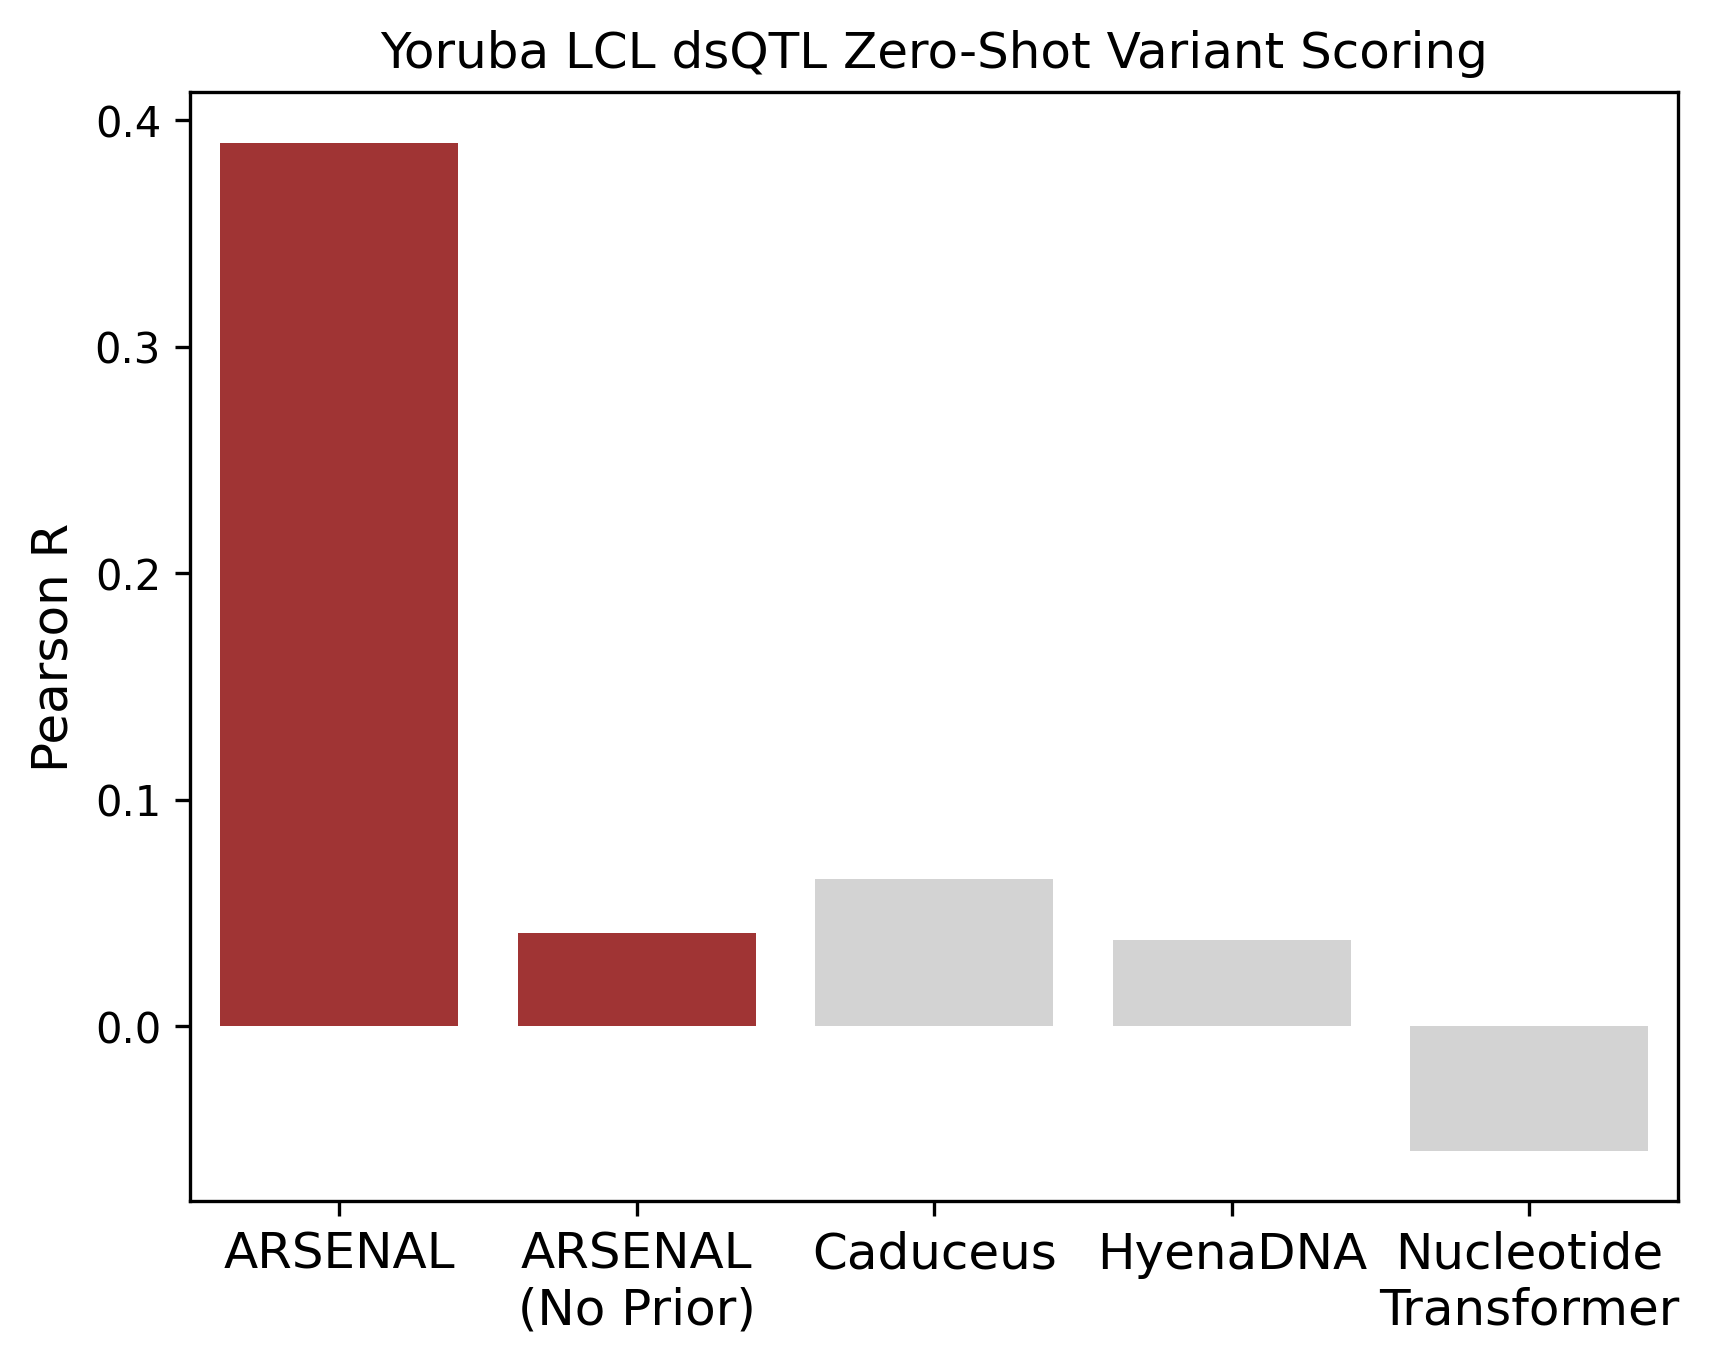

In [90]:
plt.figure(dpi=300)
acc_vals = [0.390, 0.041, 0.065, 0.038, -0.055]
models = ["ARSENAL", "ARSENAL\n(No Prior)", "Caduceus", "HyenaDNA", "Nucleotide\nTransformer"]
cats = ["Arsenal"] * 2 + ["Other"] * 3
ax = sns.barplot(x=models, y=acc_vals, hue=cats, palette=["firebrick", "lightgray"])
plt.xticks(fontsize=12)
plt.title("Yoruba LCL dsQTL Zero-Shot Variant Scoring", family="sans-serif")
plt.ylabel("Pearson R", fontsize=12)
ax.legend_.remove()


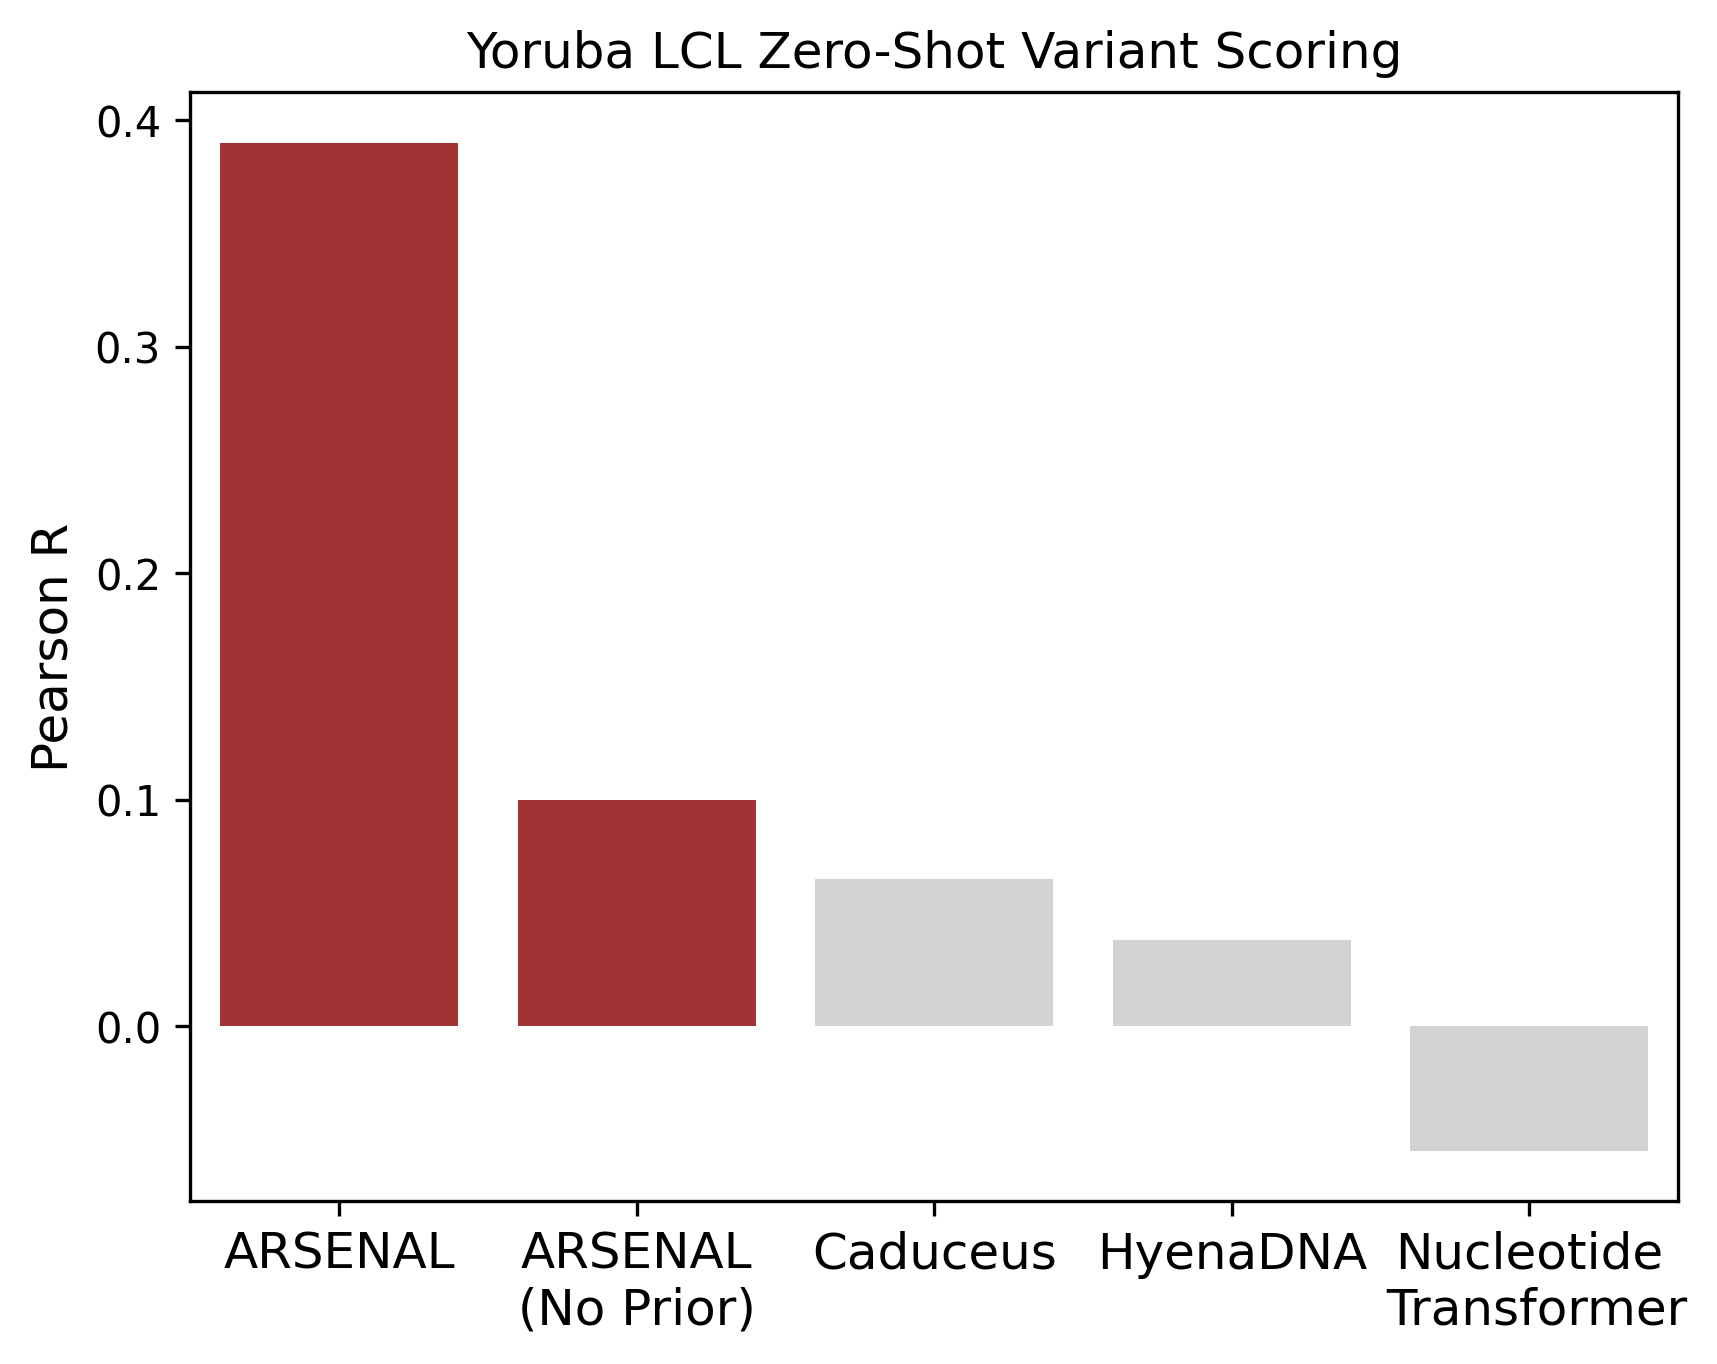

In [73]:
plt.figure(dpi=300)
acc_vals = [0.390, 0.100, 0.065, 0.038, -0.055]
models = ["ARSENAL", "ARSENAL\n(No Prior)", "Caduceus", "HyenaDNA", "Nucleotide\n Transformer"]
cats = ["Arsenal"] * 2 + ["Other"] * 3
ax = sns.barplot(x=models, y=acc_vals, hue=cats, palette=["firebrick", "lightgray"])
plt.xticks(fontsize=12)
plt.title("Yoruba LCL Zero-Shot Variant Scoring", family="sans-serif")
plt.ylabel("Pearson R", fontsize=12)
ax.legend_.remove()


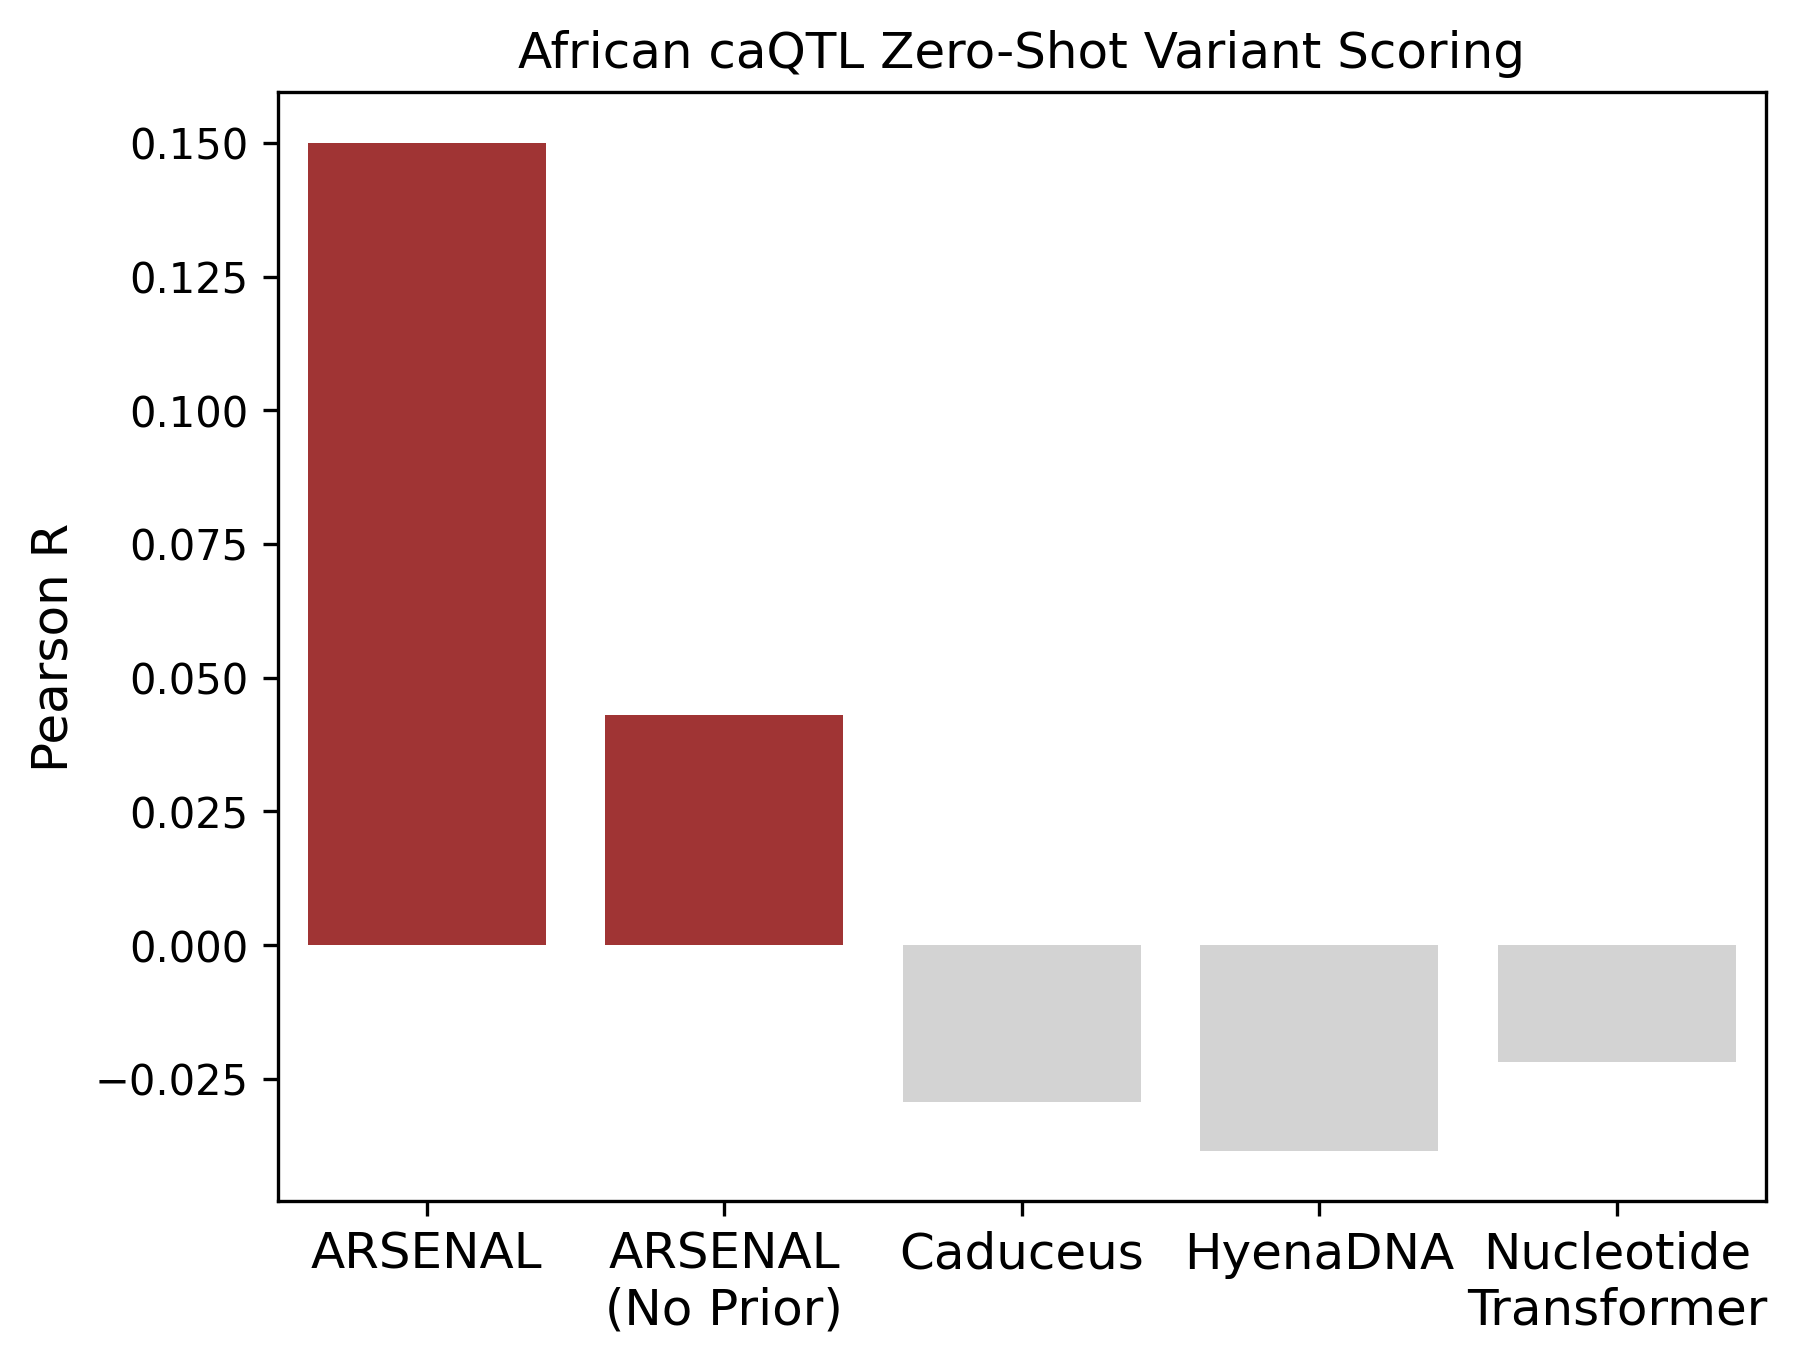

In [89]:
plt.figure(dpi=300)
acc_vals = [0.150, 0.043, -0.0293, -0.0385, -0.0218]
models = ["ARSENAL", "ARSENAL\n(No Prior)", "Caduceus", "HyenaDNA", "Nucleotide\nTransformer"]
cats = ["Arsenal"] * 2 + ["Other"] * 3
ax = sns.barplot(x=models, y=acc_vals, hue=cats, palette=["firebrick", "lightgray"])
plt.xticks(fontsize=12)
plt.title("African caQTL Zero-Shot Variant Scoring", family="sans-serif")
plt.ylabel("Pearson R", fontsize=12)
ax.legend_.remove()


In [20]:
fsig = filtered_var_yoruba_caQTLs_df_sig
problem_cases = fsig.loc[(fsig["obs.estimate"] > 0) & (fsig["llm_logfc"] < -1)].sort_values(by="llm_logfc")

problem_cases
# fsig.to_csv("/users/patelas/scratch/ccremodel.tsv", sep="\t", index=False, header=True)

In [68]:
fsig.columns

Index(['var.chrom', 'var.pos', 'var.allele1', 'var.allele2', 'var.rsid',
       'var.label', 'var.isused', 'obs.estimate',
       'pred.gkmsvm.encsr000emt.varscore.deltasvm',
       'pred.enformer.encsr000emt.varscore.global_sad',
       'pred.enformer.encsr000emt.varscore.global_sar',
       'pred.enformer.encsr000emt.varscore.local_logfc',
       'pred.chrombpnet.encsr000emt.varscore.logfc',
       'pred.chrombpnet.encsr000emt.varscore.jsd',
       'pred.chrombpnet.encsr000emt.varscore.ips',
       'pred.chrombpnet.encsr000emt.varscore.aaq',
       'pred.chrombpnet.encsr000emt.varscore.ies',
       'pred.chrombpnet.encsr000emt.varscore.jsd_x_aaq',
       'pred.chrombpnet.encsr000emt.varscore.logfc_x_aaq',
       'pred.chrombpnet.encsr637xsc.varscore.logfc',
       'pred.chrombpnet.encsr637xsc.varscore.jsd',
       'pred.chrombpnet.encsr637xsc.varscore.ips',
       'pred.chrombpnet.encsr637xsc.varscore.aaq',
       'pred.chrombpnet.encsr637xsc.varscore.ies',
       'pred.chrombpnet.en